In [1]:
import dinkum
from dinkum.vfg import Gene, Receptor, Ligand
from dinkum.vfn import Tissue
from dinkum import vfg, vfn

from dinkum.display import MultiTissuePanel, tc_record_activity
from dinkum.vfg2 import (Growth, Decay, LinearCombination, GeneTimecourse, LogisticActivator, run_lmfit,
                         LogisticRepressor, calc_response_1d, calc_response_2d, LogisticMultiRepressor)


import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from itertools import chain

initializing: dinkum v0.5.0
start=1 stop=10


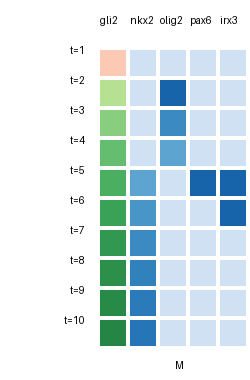

In [2]:
dinkum.reset()

m = Tissue(name='M')

shh = Ligand(name='shh')
gli2 = Receptor(name='gli2', ligand=shh)

nkx2 = Gene(name='nkx2')
olig2 = Gene(name='olig2')
pax6 = Gene(name='pax6')
irx3 = Gene(name='irx3')
ubiq = Gene(name='ubiq')


def growth_fn_shh(*, shh):
    growth = 1/4
    return shh.level + (100 - shh.level) * growth, True

def growth_fn_gli2(*, gli2):
    growth = 1/4
    return gli2.level + (100 - gli2.level) * growth, True


# CTB: make it possible to do ligand => receptor level communication
#shh.custom_activation(state_fn=growth_fn_shh)
shh.is_present(where=m, start=1)
gli2.custom_activation(state_fn=growth_fn_gli2)
ubiq.is_present(where=m, start=2)

def olig2_reg(*, gli2, nkx2, irx3):
    if gli2.level <= 50:
        return 100 - gli2.level, True

    return 0, False

def nkx2_reg(*, gli2, olig2, pax6, irx3):
    if gli2.level > 50:
        return gli2.level, True

    return 0, False

def irx3_reg(*, ubiq, nkx2, olig2):
    if nkx2.level > 60:
        return 0, False

    if olig2.level > 60:
        return 0, False

    return ubiq

def pax6_reg(*, ubiq, nkx2, olig2):
    if nkx2.level > 40:
        return 0, False

    if olig2.level > 60:
        return 0, False

    return ubiq

pax6.custom_activation(state_fn=pax6_reg)
irx3.custom_activation(state_fn=irx3_reg)
nkx2.custom_activation(state_fn=nkx2_reg)
olig2.custom_activation(state_fn=olig2_reg)

display_fn, conc_df, active_df = dinkum.run_and_display_df(start=1, stop=10,
                                                           gene_names=['gli2', 'nkx2', 'olig2', 'pax6', 'irx3'])
display_fn

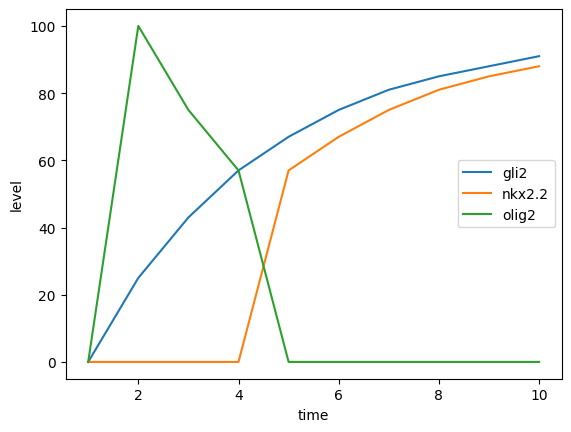

In [3]:
plt.plot(conc_df.index, conc_df.gli2, label='gli2')
plt.plot(conc_df.index, conc_df.nkx2, label='nkx2.2')
plt.plot(conc_df.index, conc_df.olig2, label='olig2')

plt.xlabel('time')
plt.ylabel('level')
plt.legend(loc='center right')

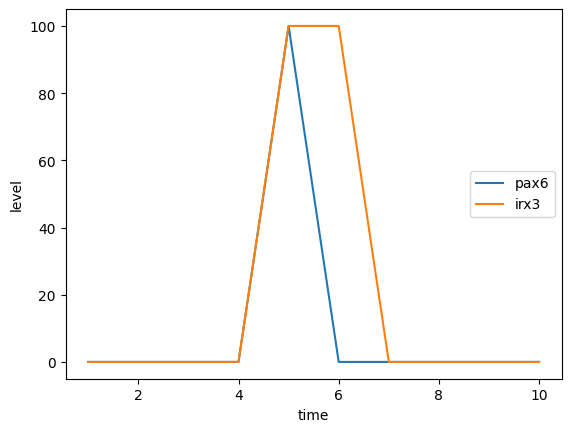

In [4]:
#plt.plot(conc_df.index, conc_df.nkx2, label='nkx2.2')
#plt.plot(conc_df.index, conc_df.olig2, label='olig2')
plt.plot(conc_df.index, conc_df.pax6, label='pax6')
plt.plot(conc_df.index, conc_df.irx3, label='irx3')


plt.xlabel('time')
plt.ylabel('level')
plt.legend(loc='center right')

initializing: dinkum v0.5.0
[0, 0, 0, 0, 0, 0, 0, 100, 0, 100, 0, 100, 0, 0, 100, 0, 100, 0, 100, 0]
start=1 stop=10


  0%|                                                  | 0/1000 [00:00<?, ?it/s]/Users/t/miniforge3/envs/py311/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|███████████████████████████████████████| 1000/1000 [00:44<00:00, 22.57it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 20;
tau: [104.95374389  64.55805034 105.98999322  70.5232296 ]
fit values:
	nkx2_rate: fit=74.03113604468301 (was: 11)
	nkx2_midpoint: fit=77.92735278876738 (was: 50.0)
	olig2_rate: fit=63.79469663349883 (was: 11)
	olig2_midpoint: fit=70.8782089521836 (was: 50.0)
start=1 stop=10


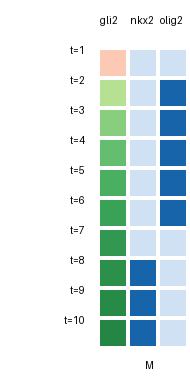

In [5]:
dinkum.reset()

m = Tissue(name='M')

shh = Ligand(name='shh')
gli2 = Receptor(name='gli2', ligand=shh)

nkx2 = Gene(name='nkx2')
olig2 = Gene(name='olig2')
pax6 = Gene(name='pax6')
irx3 = Gene(name='irx3')
ubiq = Gene(name='ubiq')


# CTB: make it possible to do ligand => receptor level communication
#shh.custom_activation(state_fn=growth_fn_shh)
shh.is_present(where=m, start=1)
gli2.custom_activation(state_fn=growth_fn_gli2)
ubiq.is_present(where=m, start=1)

irx3.custom2(LogisticMultiRepressor(activator_name='ubiq',
                                    repressor_names=['nkx2', 'olig2'],
                                    weights=[0.6, 0.4],
#                                    weights=[1, 1],
                                    rate=50))

pax6.custom2(LogisticMultiRepressor(activator_name='ubiq',
                                    repressor_names=['nkx2', 'olig2'],
                                    weights=[0.4, 0.6],
#                                    weights=[1, 1],
                                    rate=50))

nkx2.custom2(LogisticActivator(activator_name='gli2'))
olig2.custom2(LogisticRepressor(activator_name='ubiq', repressor_name='gli2'))

nkx2_goal = [0]*7 + [100]*3
olig2_goal = [0]*3 + [100]*3 + [0]*4

total_goal = list(chain.from_iterable(zip(nkx2_goal, olig2_goal)))
print(total_goal)

run_lmfit(1, 10, total_goal, [nkx2, olig2], method='emcee')

display_fn, conc_df, active_df = dinkum.run_and_display_df(start=1, stop=10,
                                                           gene_names=['gli2', 'nkx2', 'olig2']) #, 'pax6', 'irx3'])
display_fn

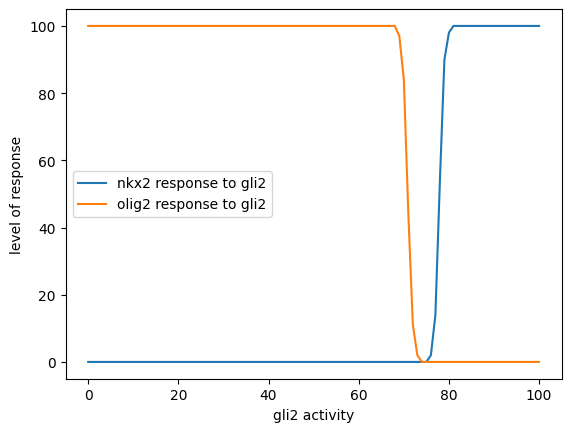

In [6]:
xvals, yvals_nkx2 = calc_response_1d(timepoint=2, target_gene_name='nkx2', variable_gene_name='gli2')
plt.plot(xvals, yvals_nkx2, label='nkx2 response to gli2')

xvals, yvals_olig2 = calc_response_1d(timepoint=2, target_gene_name='olig2', variable_gene_name='gli2',
                                     fixed_gene_states = {'ubiq': vfg.GeneStateInfo(100, True)})
plt.plot(xvals, yvals_olig2, label='olig2 response to gli2')
plt.xlabel('gli2 activity')
plt.ylabel('level of response')

plt.legend()